#**1. Imports & Settings**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold,cross_validate,cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report,roc_curve, auc
import joblib
from preprocessor import CustomPreprocessor

# **2. Load Data**


In [62]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

df = pd.concat([train, test], axis=0, ignore_index=True)
df.columns = [re.sub(r'\s+', '_', col.strip().lower()) for col in df.columns]

# **3. EDA**

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   unnamed:_0                         129880 non-null  int64  
 1   id                                 129880 non-null  int64  
 2   gender                             129880 non-null  object 
 3   customer_type                      129880 non-null  object 
 4   age                                129880 non-null  int64  
 5   type_of_travel                     129880 non-null  object 
 6   class                              129880 non-null  object 
 7   flight_distance                    129880 non-null  int64  
 8   inflight_wifi_service              129880 non-null  int64  
 9   departure/arrival_time_convenient  129880 non-null  int64  
 10  ease_of_online_booking             129880 non-null  int64  
 11  gate_location                      1298

In [64]:
pd.set_option('display.max_colum',None)

df.head()

,unnamed:_0,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [65]:
df.tail()

,unnamed:_0,id,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
129875,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,4,3,4,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
129876,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,4,4,4,4,4,5,5,5,5,4,0,0.0,satisfied
129877,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,2,1,2,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
129878,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,4,4,4,4,3,2,5,4,5,4,0,0.0,satisfied
129879,25975,34799,Female,Loyal Customer,42,Personal Travel,Eco,264,2,5,2,5,4,2,2,1,1,2,1,1,1,1,0,0.0,neutral or dissatisfied


In [66]:
df.shape

(129880, 25)

In [67]:
df.nunique().to_frame(name='Number of Classes')

,Number of Classes
unnamed:_0,103904
id,129880
gender,2
customer_type,2
age,75
type_of_travel,2
class,3
flight_distance,3821
inflight_wifi_service,6
departure/arrival_time_convenient,6


In [68]:
df.describe()

,unnamed:_0,id,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [69]:
df.describe(include='object')

,gender,customer_type,type_of_travel,class,satisfaction
count,129880,129880,129880,129880,129880
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,65899,106100,89693,62160,73452


In [70]:
df.isna().sum().sort_values()

unnamed:_0                             0
departure_delay_in_minutes             0
cleanliness                            0
inflight_service                       0
checkin_service                        0
baggage_handling                       0
leg_room_service                       0
on-board_service                       0
inflight_entertainment                 0
seat_comfort                           0
online_boarding                        0
food_and_drink                         0
ease_of_online_booking                 0
departure/arrival_time_convenient      0
inflight_wifi_service                  0
flight_distance                        0
class                                  0
type_of_travel                         0
age                                    0
customer_type                          0
gender                                 0
id                                     0
gate_location                          0
satisfaction                           0
arrival_delay_in

In [71]:
cat_columns = ['gender', 'customer_type', 'type_of_travel', 'class','satisfaction']

num_columns = ['age', 'flight_distance', 'departure_delay_in_minutes', 'arrival_delay_in_minutes']

rating_columns = ['inflight_wifi_service','departure/arrival_time_convenient','ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on-board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service','cleanliness']


In [72]:
print(np.unique(df[rating_columns]))

[0 1 2 3 4 5]


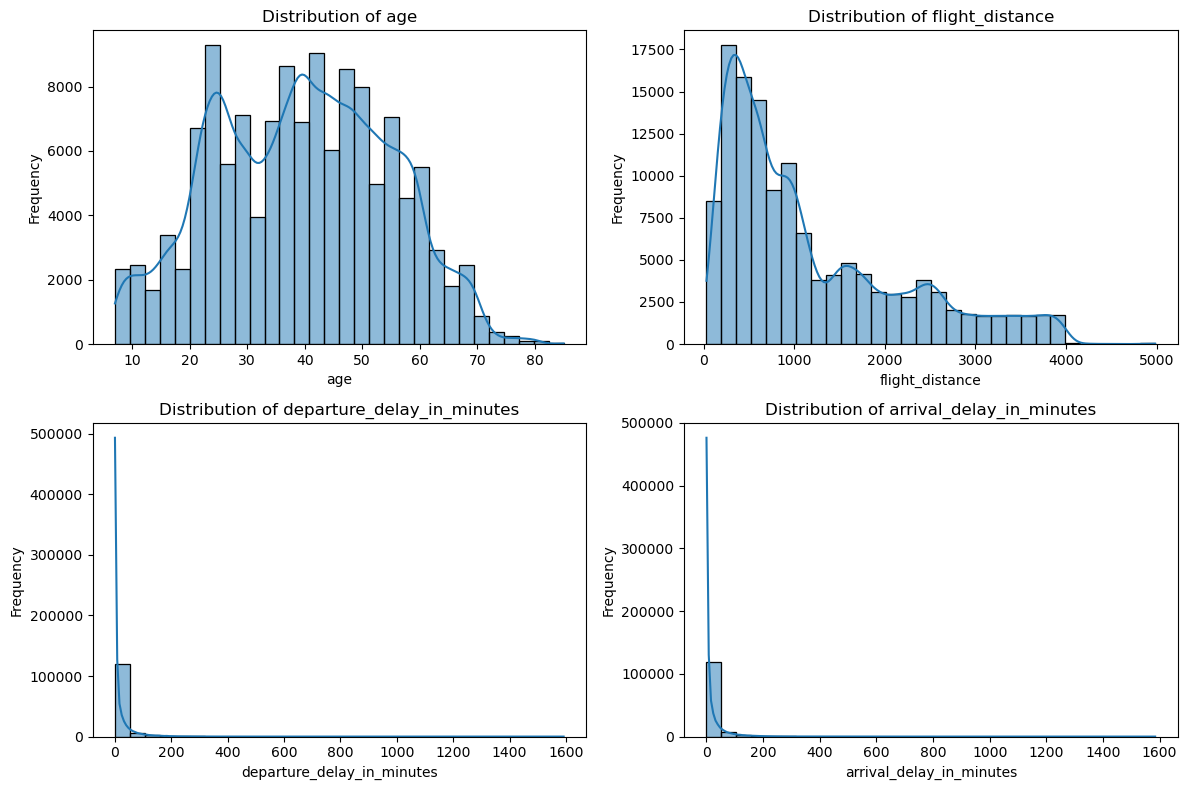

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [74]:
satisfaction_counts = df['satisfaction'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(satisfaction_counts, labels=satisfaction_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Customer Satisfaction')
plt.axis('equal')

(-1.0999984921614492,
 1.0999878233389853,
 -1.0999996201117743,
 1.0999932069444474)

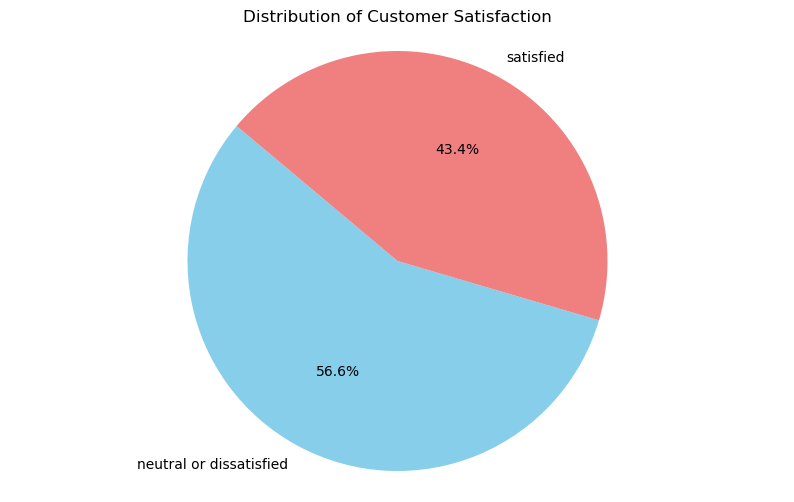

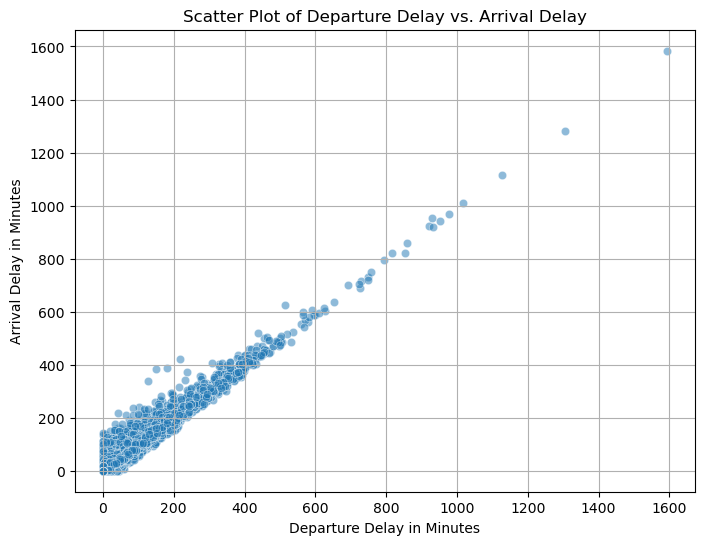

In [75]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='departure_delay_in_minutes', y='arrival_delay_in_minutes', alpha=0.5)
plt.title('Scatter Plot of Departure Delay vs. Arrival Delay')
plt.xlabel('Departure Delay in Minutes')
plt.ylabel('Arrival Delay in Minutes')
plt.grid(True)
plt.show()

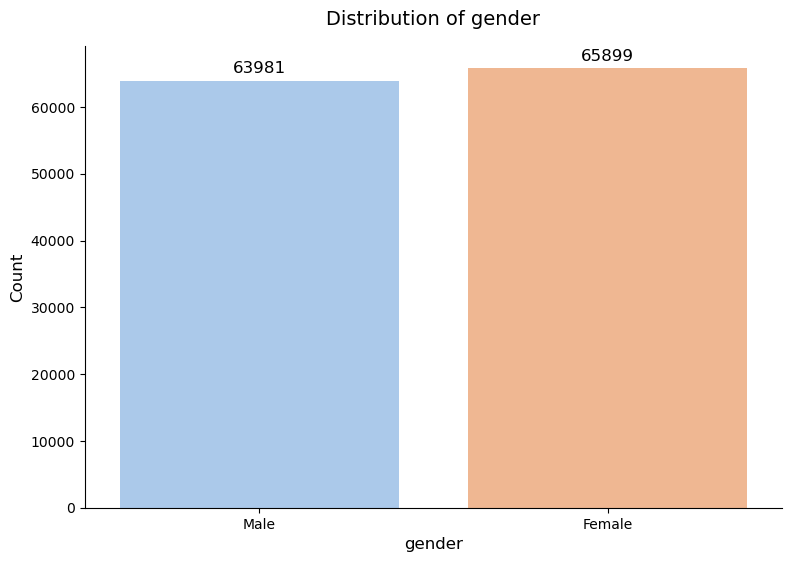

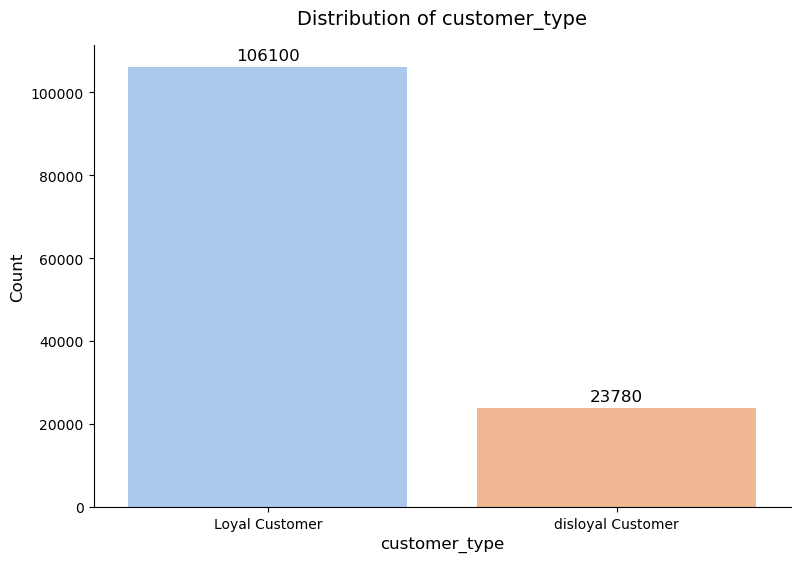

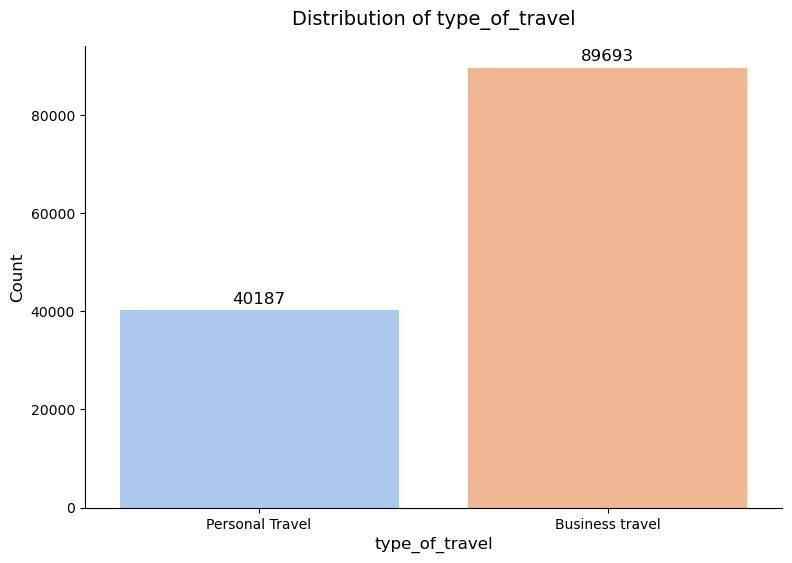

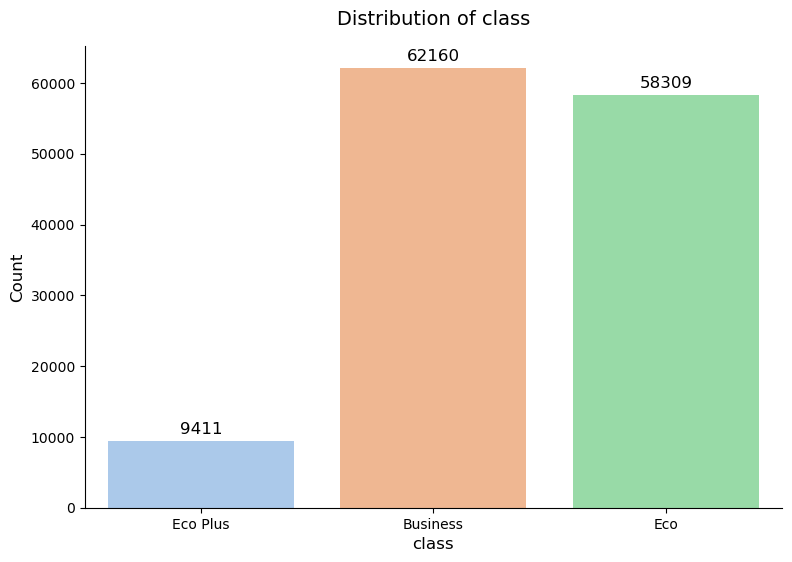

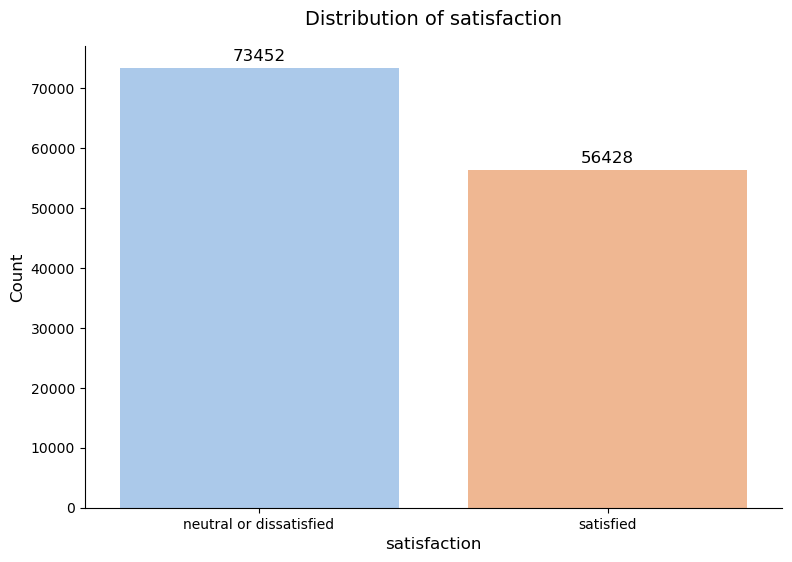

In [76]:
warnings.filterwarnings('ignore')

for col in cat_columns:
    plt.figure(figsize=(9, 6))

    ax = sns.countplot(x=col, data=df,palette='pastel')

    for container in ax.containers:
        ax.bar_label(container, fontsize=12, padding=3)

    plt.title(f'Distribution of {col}', fontsize=14, pad=15)
    plt.ylabel('Count', fontsize=12)
    plt.xlabel(col, fontsize=12)

    sns.despine()

    plt.show()

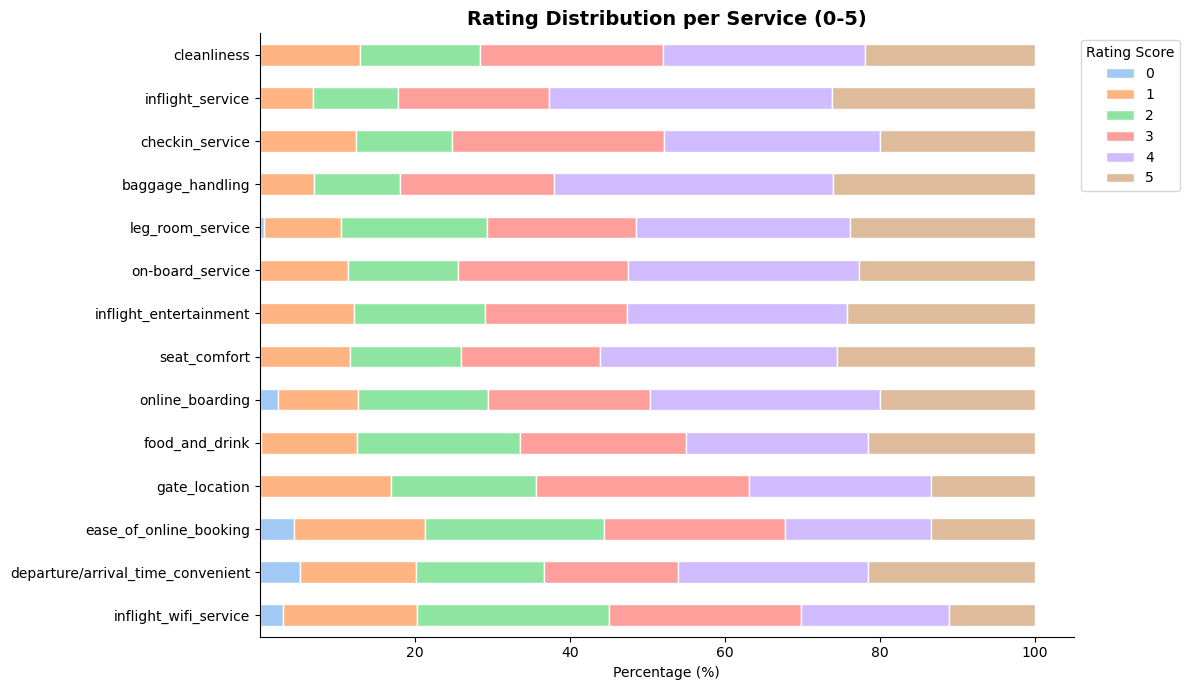

In [77]:
dist_df = df[rating_columns].apply(lambda x: x.value_counts(normalize=True)).T.sort_index(axis=1) * 100

ax = dist_df.plot(kind='barh', stacked=True, figsize=(12, 7),
                  color=sns.color_palette('pastel', 6), edgecolor='white')

plt.title('Rating Distribution per Service (0-5)', fontsize=14, fontweight='bold')
plt.legend(title='Rating Score', bbox_to_anchor=(1, 1), loc='upper left')
plt.xlabel('Percentage (%)')
sns.despine()
plt.tight_layout()

plt.show()

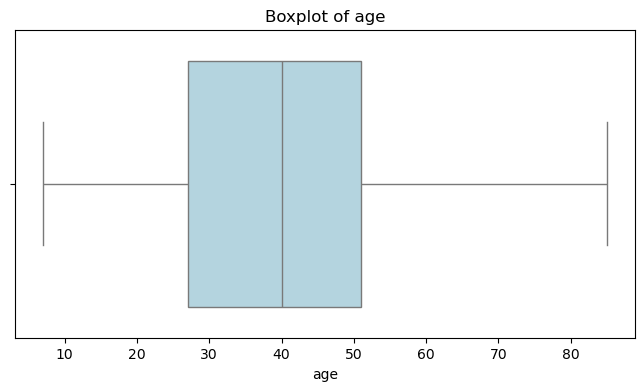

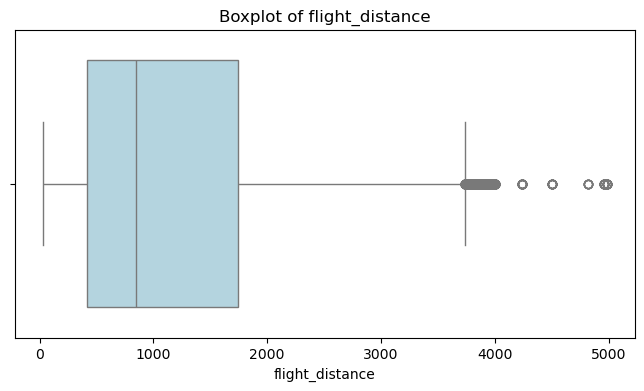

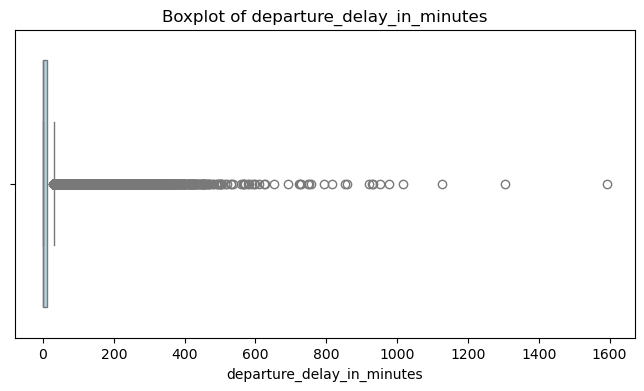

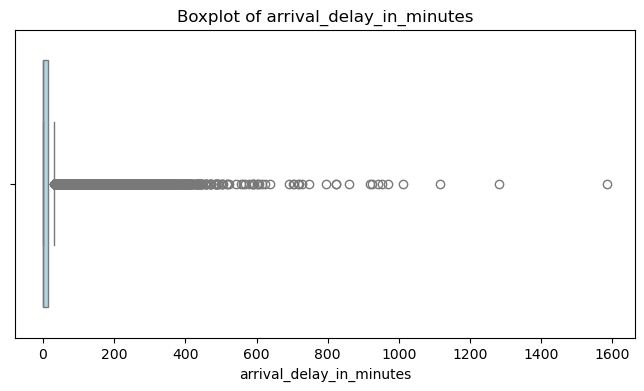

In [78]:
for col in num_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color="lightblue")
    plt.title(f'Boxplot of {col}')
    plt.show()

#**4. Train / Test Split**

In [79]:
target_mapping = {'neutral or dissatisfied': 0, 'satisfied': 1}
y = df['satisfaction'].map(target_mapping)
X = df.drop('satisfaction', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape,X_test.shape

((90916, 24), (38964, 24))

#**5. Preprocessing with ColumnTransformer + Pipeline**

In [80]:
pipeline = Pipeline(steps=[
    ('preprocessing', CustomPreprocessor()),
    ('model', RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42))])

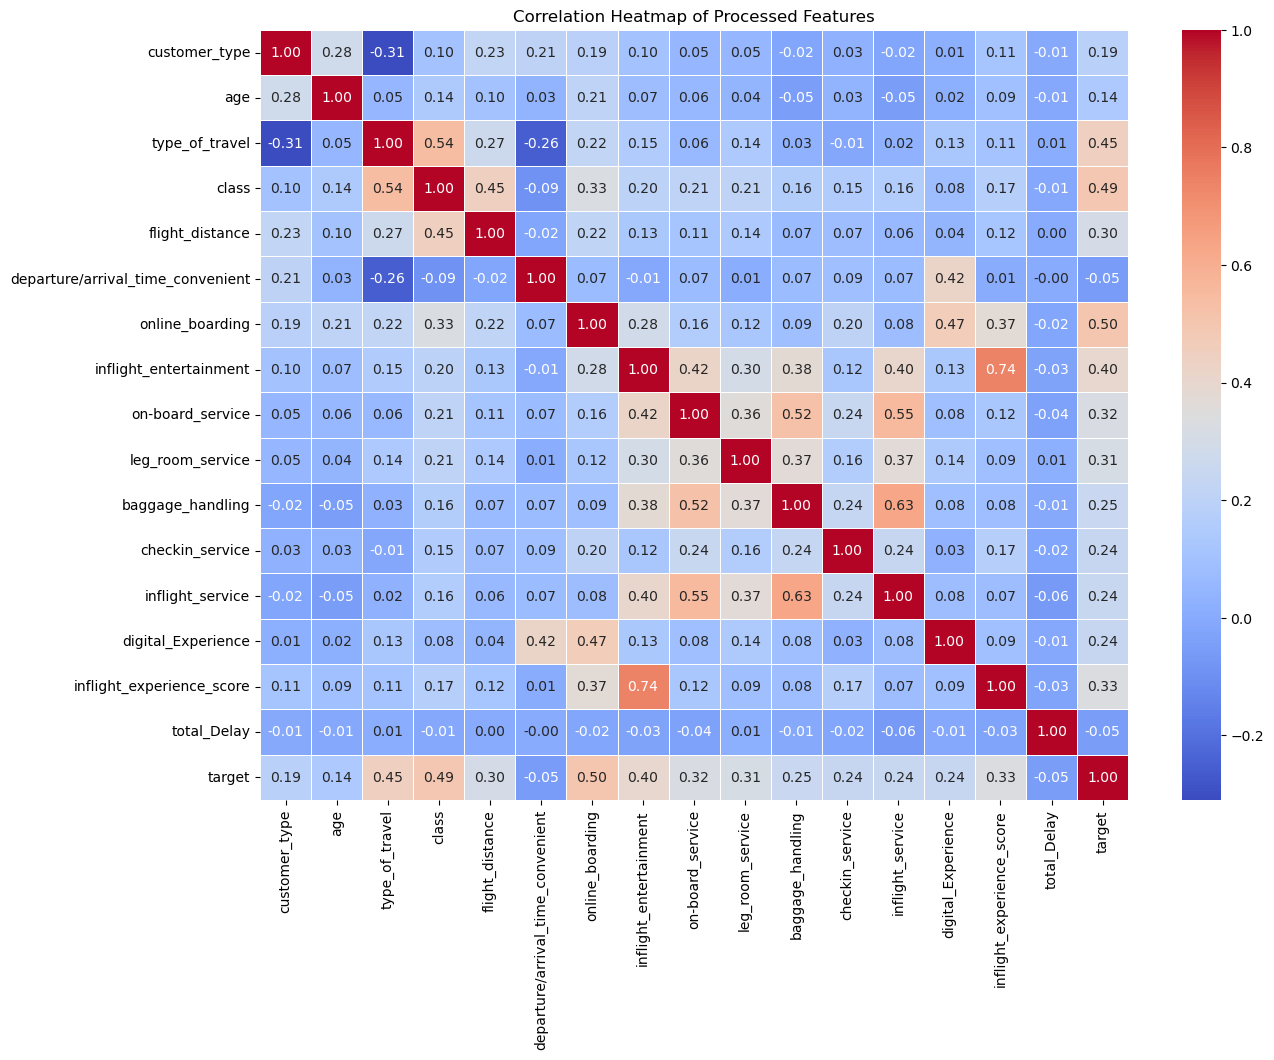

In [81]:
preprocessor_step = pipeline.steps[0][1]
X_transformed = preprocessor_step.transform(X_train)
X_transformed['target'] = y_train.values
plt.figure(figsize=(14, 10))
sns.heatmap(X_transformed.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Processed Features')
plt.show()

In [82]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing', CustomPreprocessor()),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

#**5. Model Evaluation and Visualization**

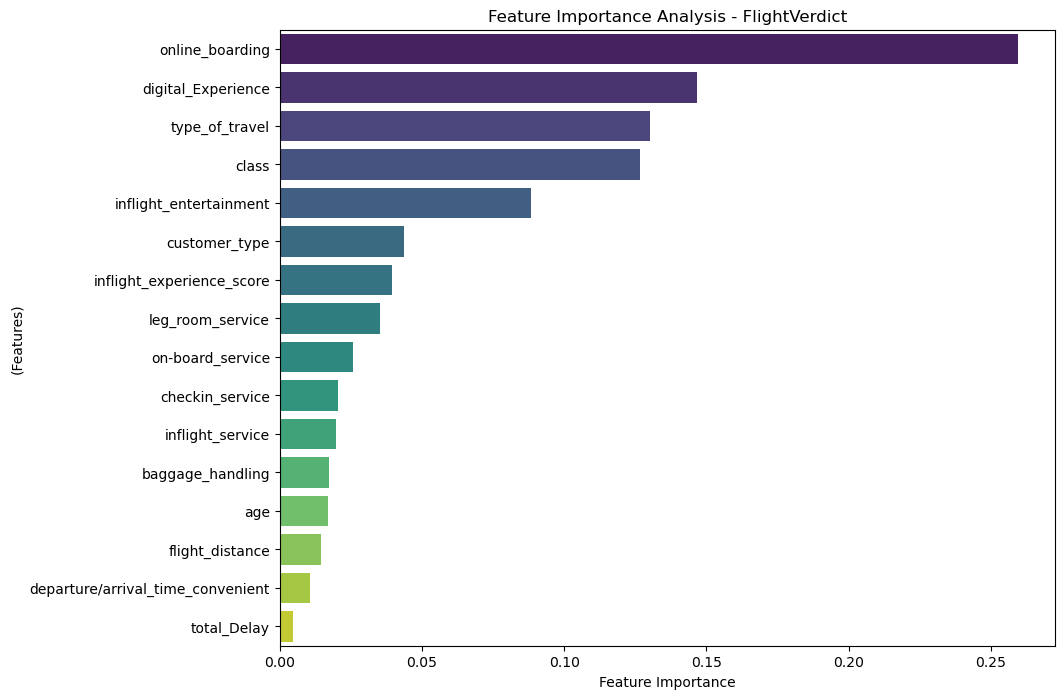

In [83]:
model_step = pipeline.steps[-1][1] 
preprocessor_step = pipeline.steps[0][1]
X_sample = preprocessor_step.transform(X_train.head(1))
feature_names = X_sample.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model_step.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance Analysis - FlightVerdict')
plt.xlabel('Feature Importance')
plt.ylabel('(Features)')
plt.show()

In [84]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'}

results = cross_validate(pipeline, X, y, cv=kf, scoring=scoring_metrics)
print(f"1.(Accuracy): {results['test_accuracy'].mean()*100:.2f}%")
print(f"2.(Precision): {results['test_precision'].mean()*100:.2f}%")
print(f"3.(Recall): {results['test_recall'].mean()*100:.2f}%")
print(f"4.(F1-Score): {results['test_f1'].mean()*100:.2f}%")
print(f"5.(AUC Score): {results['test_roc_auc'].mean()*100:.4f}%")

1.(Accuracy): 94.01%
2.(Precision): 93.88%
3.(Recall): 92.22%
4.(F1-Score): 93.04%
5.(AUC Score): 98.6699%


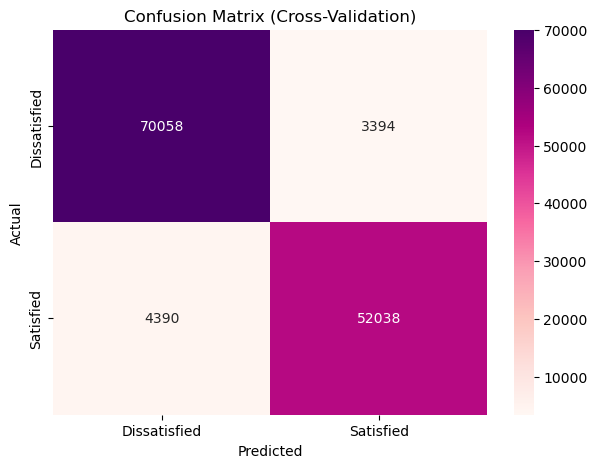

In [85]:
y_pred_cv = cross_val_predict(pipeline, X, y, cv=kf)
cm = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu')
plt.title('Confusion Matrix (Cross-Validation)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.xticks([0.5, 1.5], ['Dissatisfied', 'Satisfied'])
plt.yticks([0.5, 1.5], ['Dissatisfied', 'Satisfied'])

plt.show()

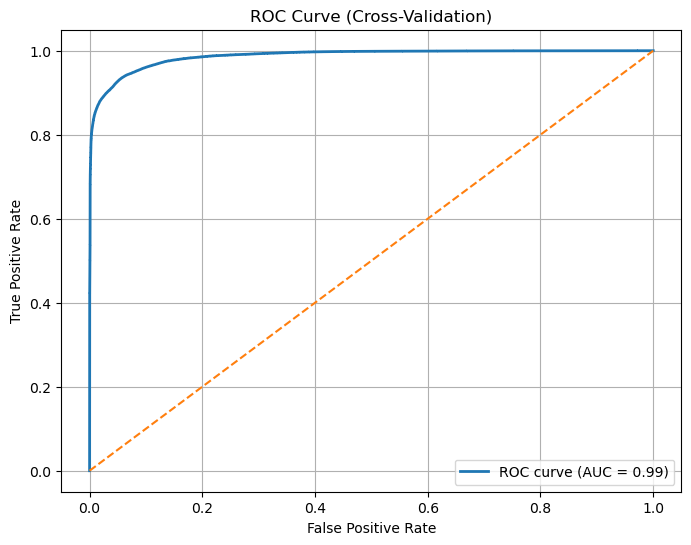

In [86]:
y_prob_cv = cross_val_predict(
    pipeline,X,y,cv=kf,method='predict_proba')[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_prob_cv)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Cross-Validation)')
plt.legend()
plt.grid(True)
plt.show()

# **6. Save the Model**

In [25]:
joblib.dump(pipeline, 'model.joblib')

['model.joblib']